In [1]:
from utils.generate_users import Simulated_User

user1 = Simulated_User()

In [2]:
user1.get_clothing_preferences()

{'style': {'CASUAL': 0.14314155551917535,
  'PREPPY': 0.1529519149030446,
  'STREETWEAR': 0.14431397172671193,
  'MINIMALIST': 0.15249782395747638,
  'VINTAGE': 0.11949743969484446,
  'SPORTY': 0.13263676329924368,
  'ATHLEISURE': 0.1549605308995036},
 'clothing_type': {'T-SHIRT': 0.14868106482476212,
  'SWEATER': 0.020643260485716526,
  'HOODIE': 0.04518764871271541,
  'JACKET': 0.05599440636985618,
  'JEANS': 0.08794496335961731,
  'COAT': 0.04660198247261003,
  'SHORTS': 0.08802508972012263,
  'TANK_TOP': 0.11751685791662966,
  'SKIRT': 0.07831078538861118,
  'DRESS': 0.08462158729133448,
  'ACTIVEWEAR': 0.0677116074770174,
  'POLO': 0.02163946444208554,
  'BUTTON_DOWN_SHIRT': 0.043214684609254185,
  'PANTS': 0.048016316232504644,
  'T_SHIRT': 0.018784847794492295,
  'SWIMWEAR': 0.027105432902670427},
 'fitting': {'SLIM_FIT': 0.19252602761380488,
  'REGULAR_FIT': 0.32302992966242194,
  'OVERSIZED': 0.2495279595358935,
  'SKINNY': 0.23491608318787957},
 'sizing': {'XS': 0.0,
  'S': 0

In [3]:
user1.get_latent_variables()

{'comfort_preference': 0.6107984358823373,
 'practicality': 0.5494451164945261,
 'status_signaling': 0.28740601764222184,
 'modesty': 0.7413982634500632,
 'sustainability': 0.6816988226096957,
 'risk_risk_tolerance': 0.39895422309909534,
 'trend_sensitivity': 0.4182109497994345}

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from utils.generate_users import Simulated_User

# Number of users
num_users = 1000

# Lists to store data
clothing_data = []
latent_data = []

# Generate users
for _ in range(num_users):
    user = Simulated_User()
    clothing_data.append(user.get_clothing_preferences())
    latent_data.append(user.get_latent_variables())

# Convert to DataFrames
df_clothing = pd.DataFrame(clothing_data)
df_latent = pd.DataFrame(latent_data)






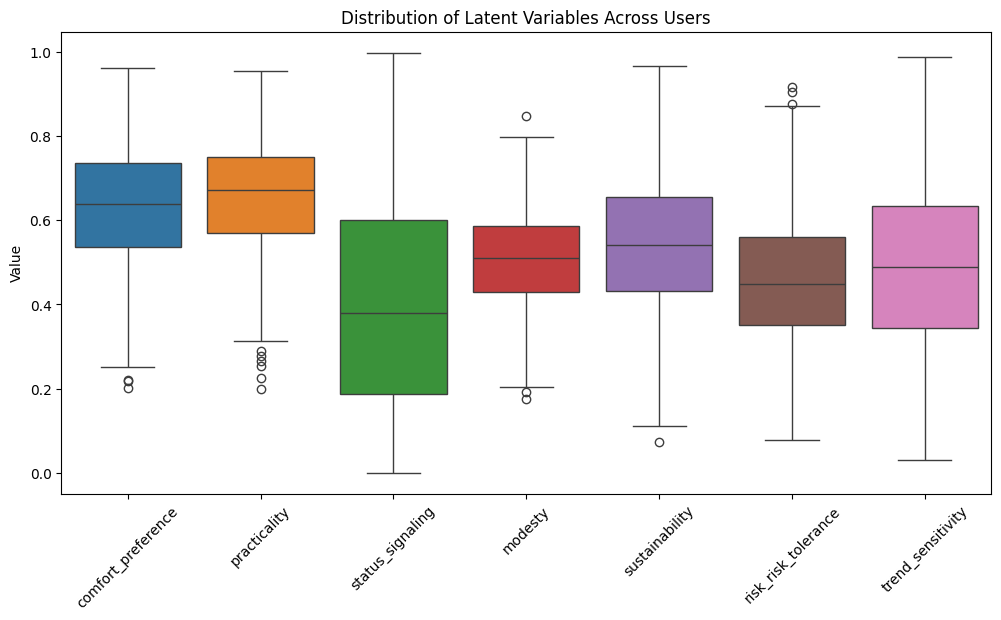

In [5]:
# ----------------------
# 1️⃣ Aggregate distributions for latent variables
# ----------------------
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_latent)
plt.title("Distribution of Latent Variables Across Users")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()


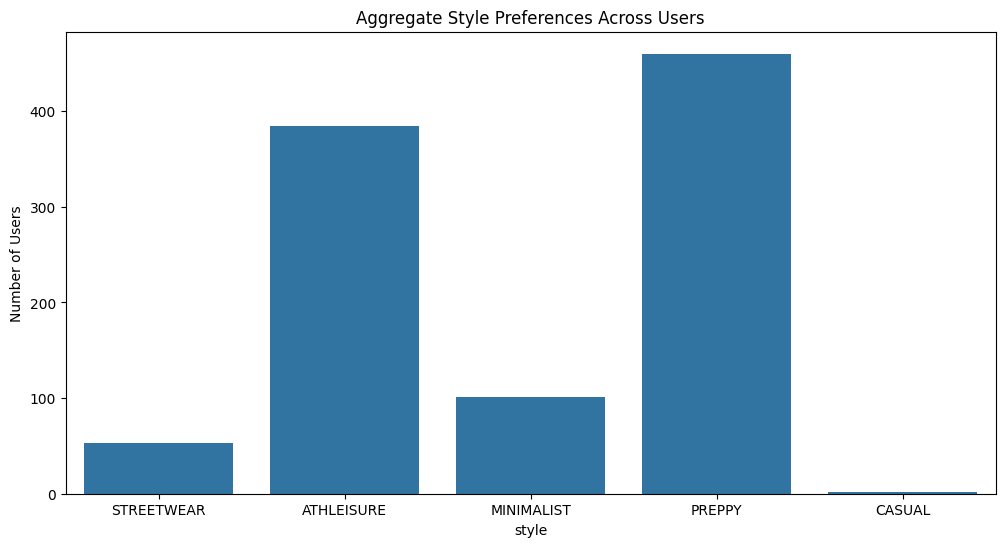

In [6]:

# ----------------------
# 2️⃣ Aggregate distributions for clothing preferences
# We'll pick one aspect like 'style'
# ----------------------
# Assuming get_clothing_preferences() returns probability dicts, we can convert them to categorical picks
# Pick the highest probability option for simplicity
df_clothing_cat = df_clothing.apply(lambda row: row.apply(lambda x: max(x, key=x.get)), axis=1)

plt.figure(figsize=(12, 6))
sns.countplot(x='style', data=df_clothing_cat)
plt.title("Aggregate Style Preferences Across Users")
plt.ylabel("Number of Users")
plt.show()

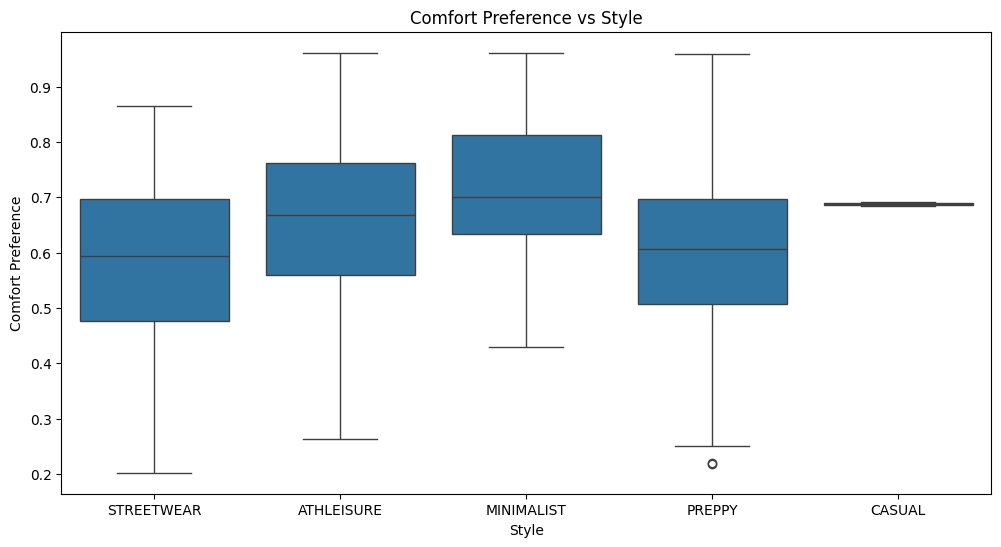

In [7]:
# ----------------------
# 3️⃣ Explore relationships between latent variables and clothing preferences
# Example: 'comfort_preference' vs 'style'
# ----------------------
# Merge latent and clothing data
df_combined = pd.concat([df_latent, df_clothing_cat], axis=1)

plt.figure(figsize=(12, 6))
sns.boxplot(x='style', y='comfort_preference', data=df_combined)
plt.title("Comfort Preference vs Style")
plt.ylabel("Comfort Preference")
plt.xlabel("Style")
plt.show()

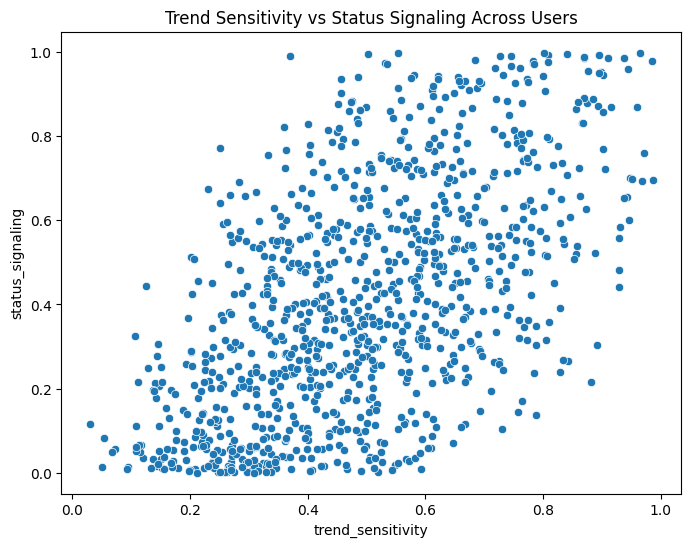

In [8]:

# Another example: scatter latent vs latent
plt.figure(figsize=(8, 6))
sns.scatterplot(x='trend_sensitivity', y='status_signaling', data=df_latent)
plt.title("Trend Sensitivity vs Status Signaling Across Users")
plt.show()


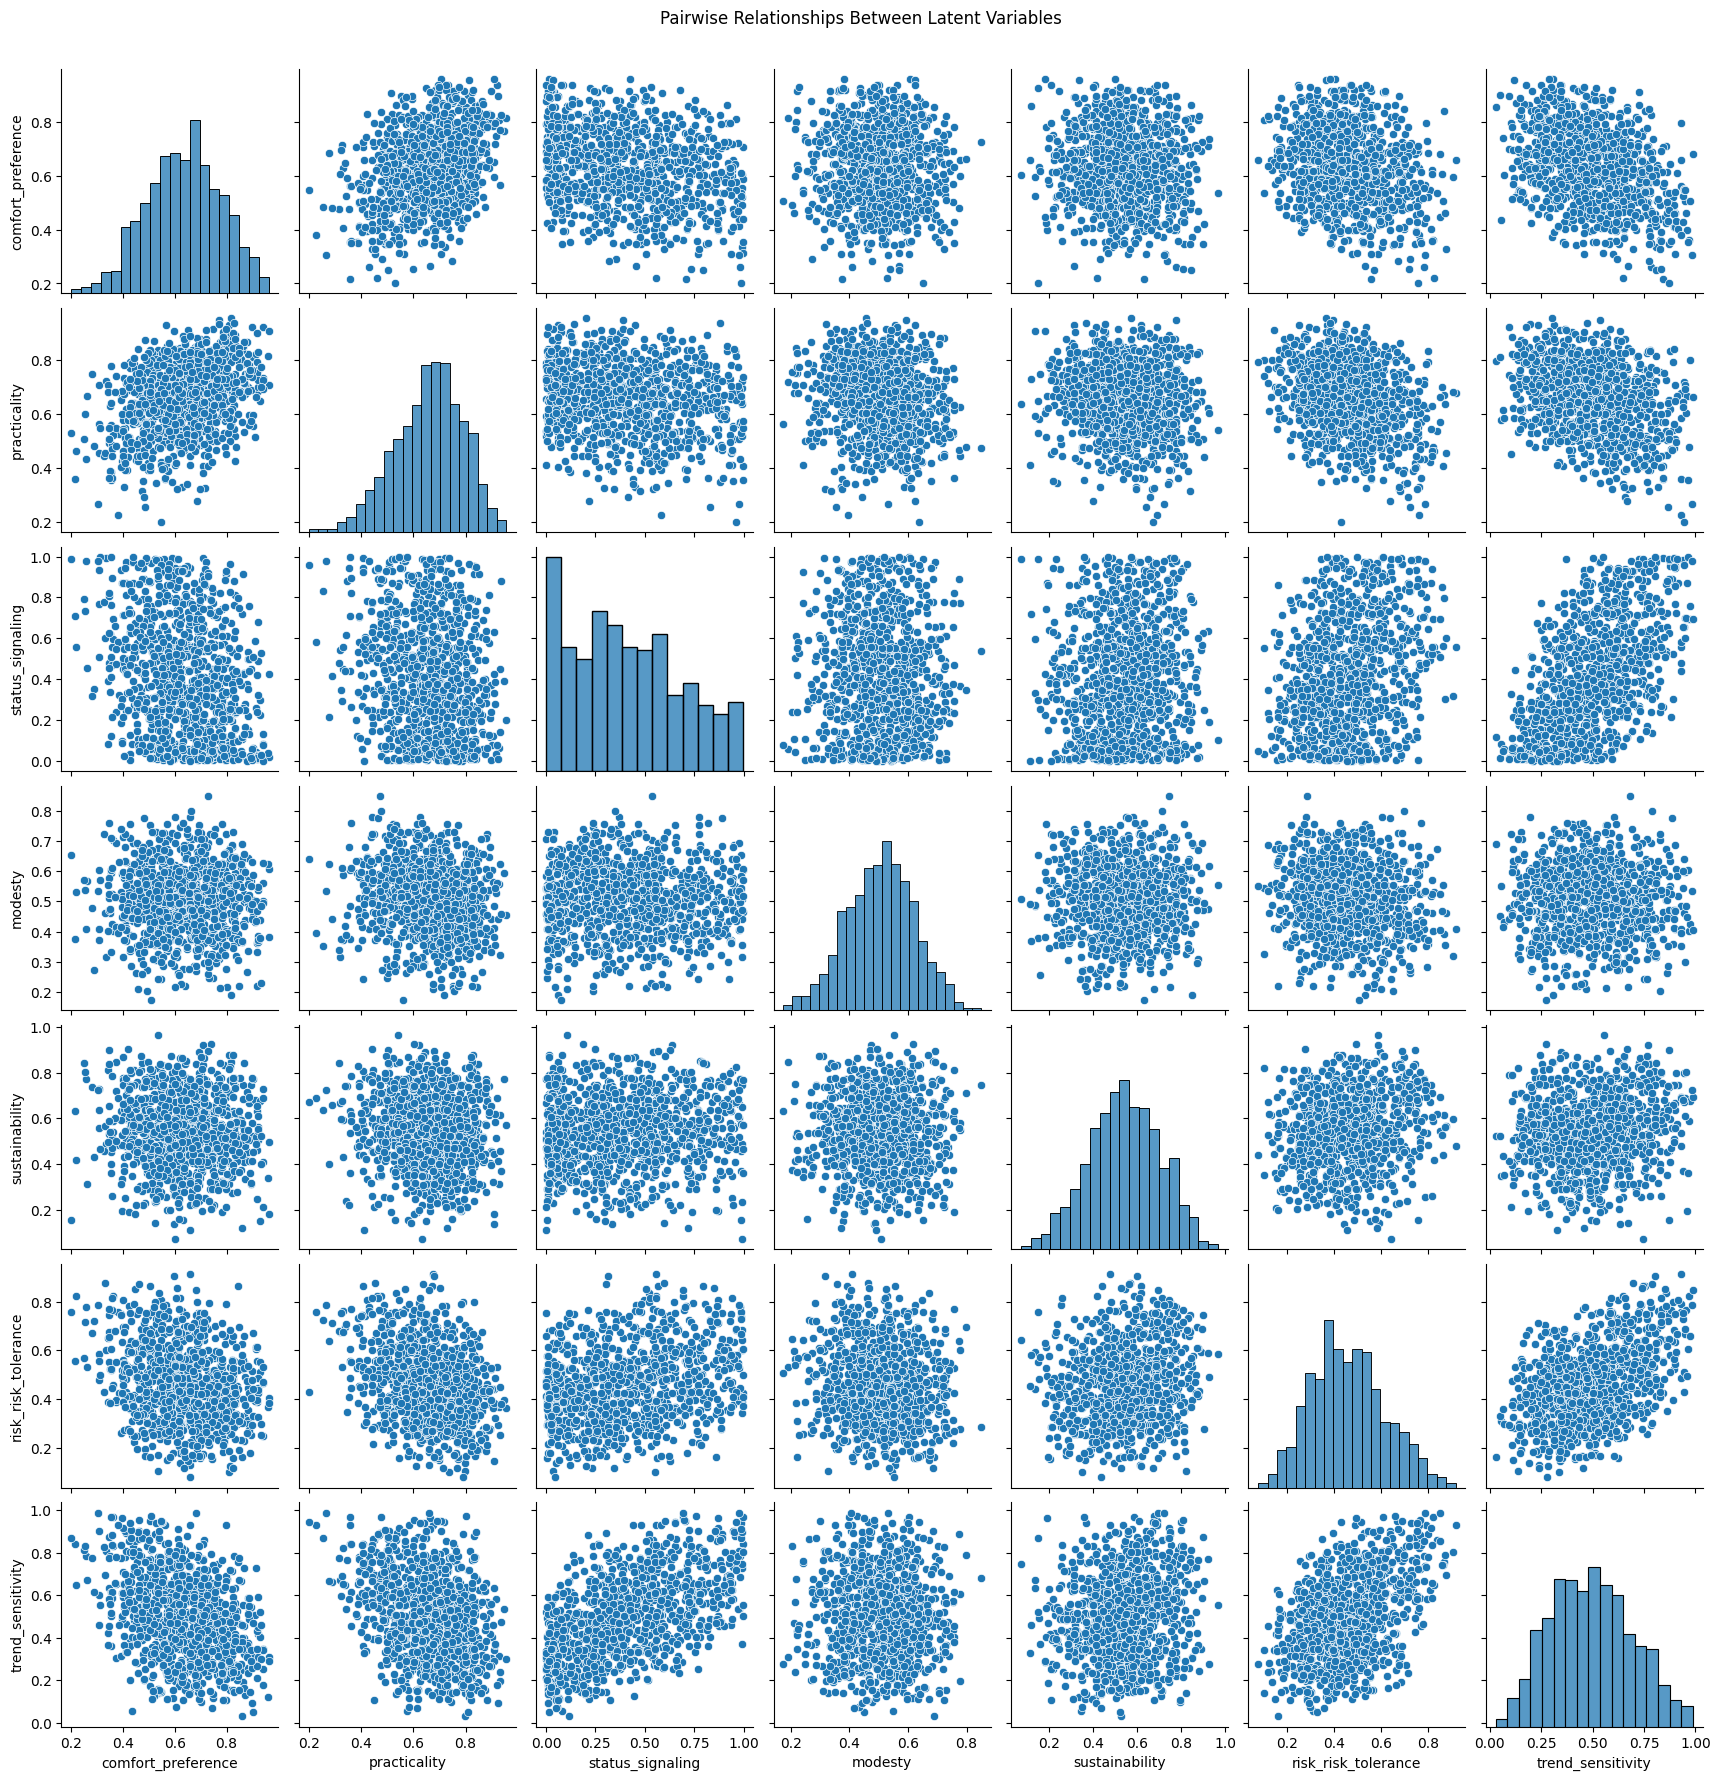

In [9]:

# ----------------------
# 4️⃣ Optional: Pairplot for latent variables
# ----------------------
sns.pairplot(df_latent)
plt.suptitle("Pairwise Relationships Between Latent Variables", y=1.02)
plt.show()

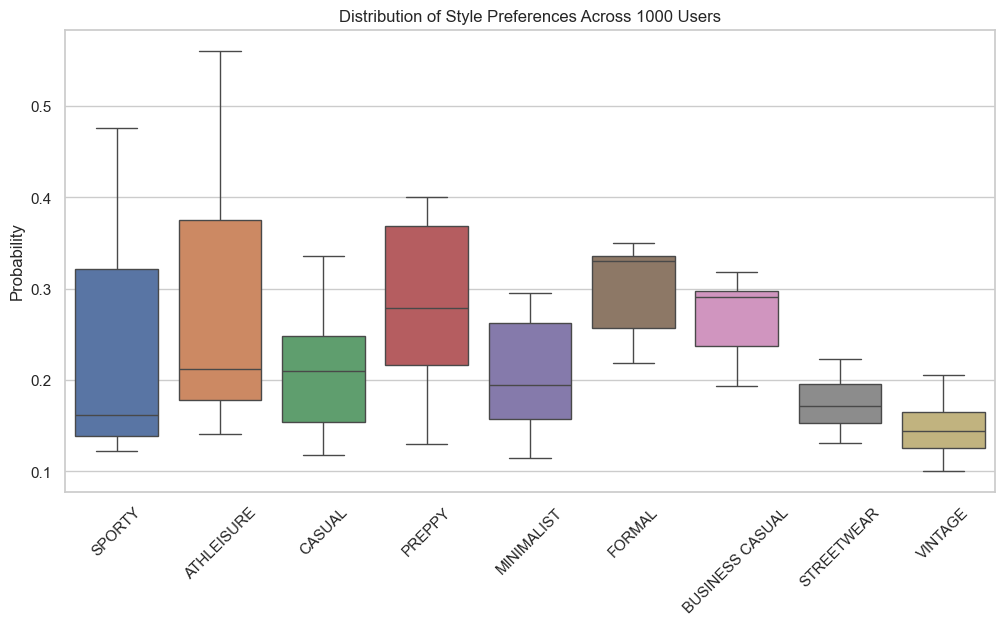

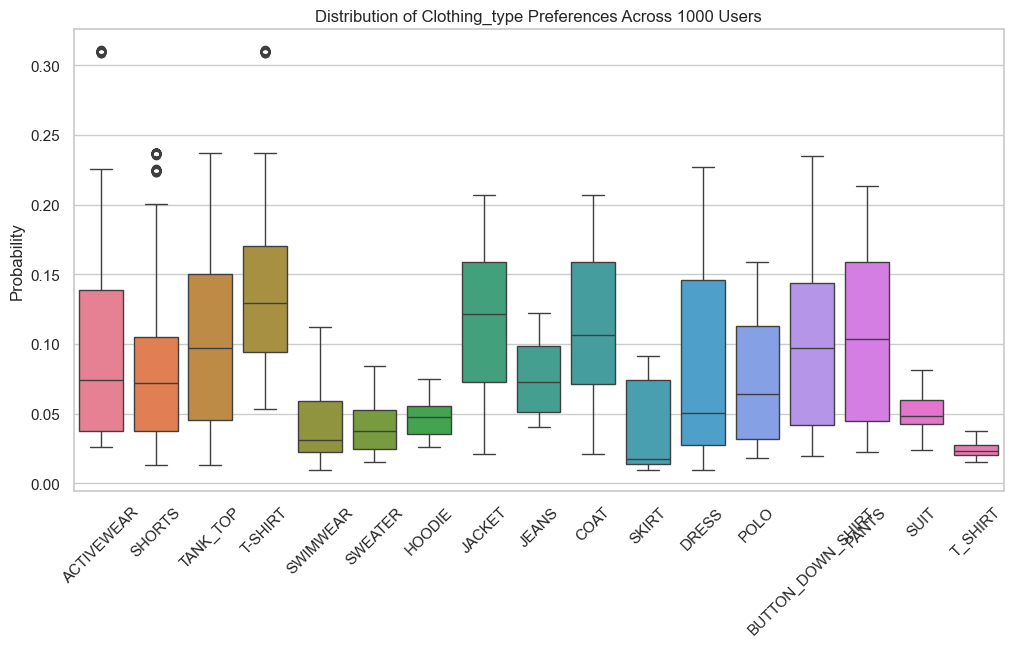

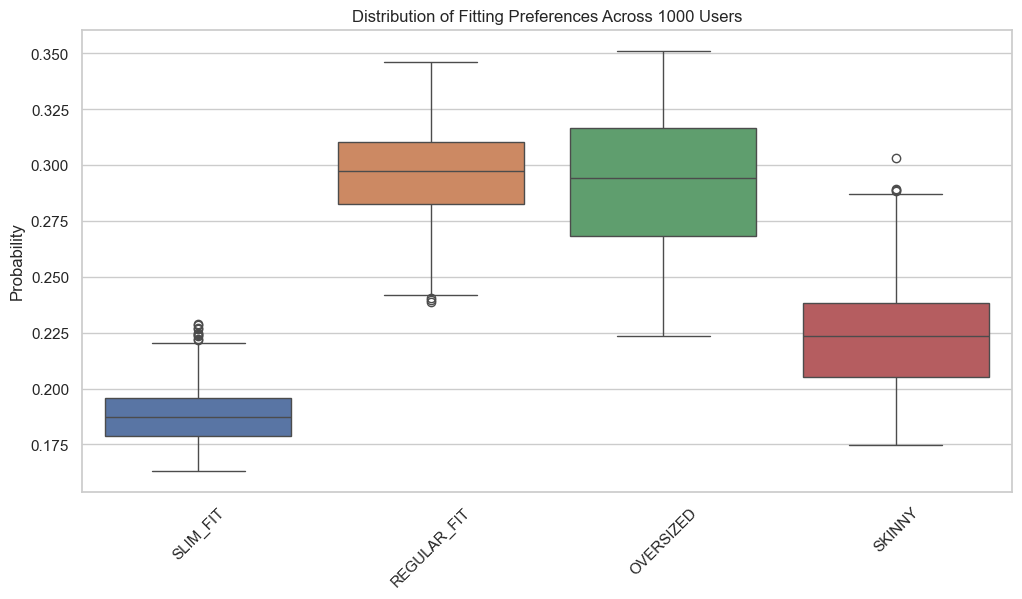

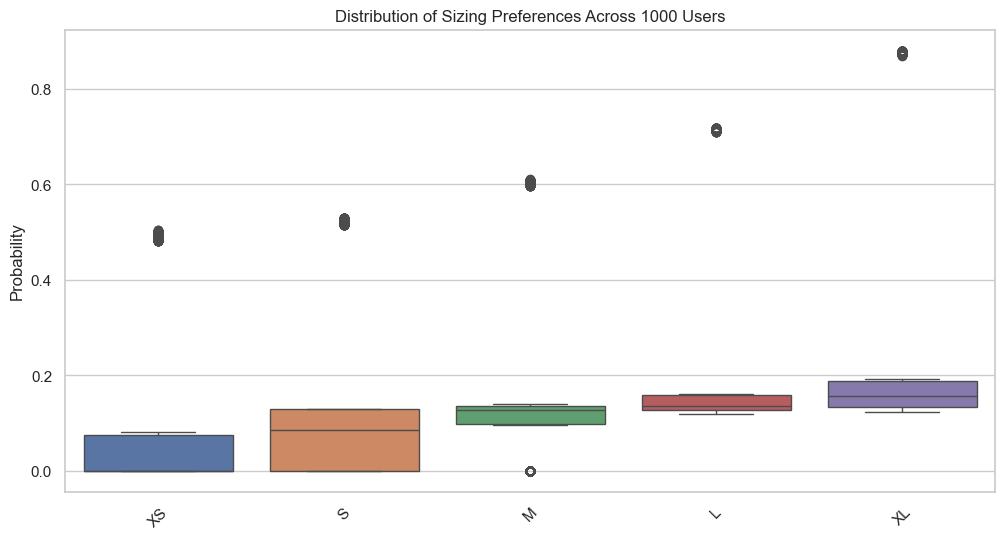

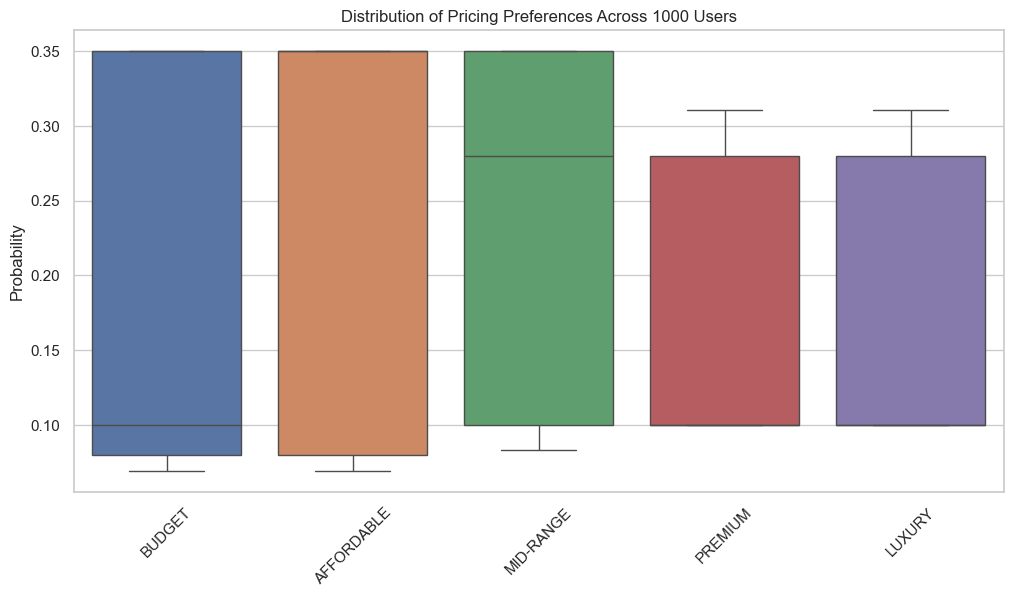

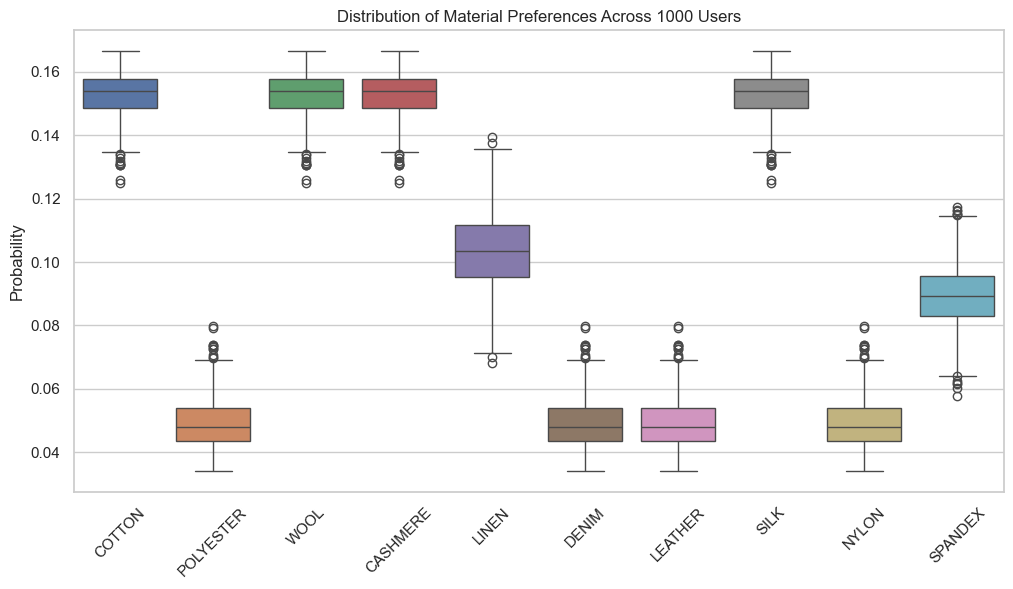

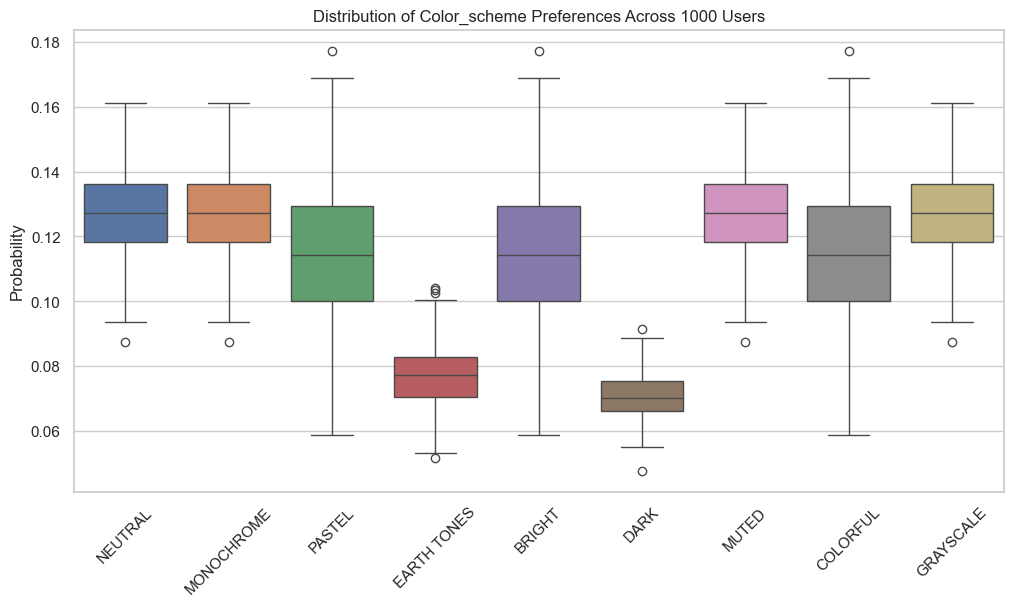

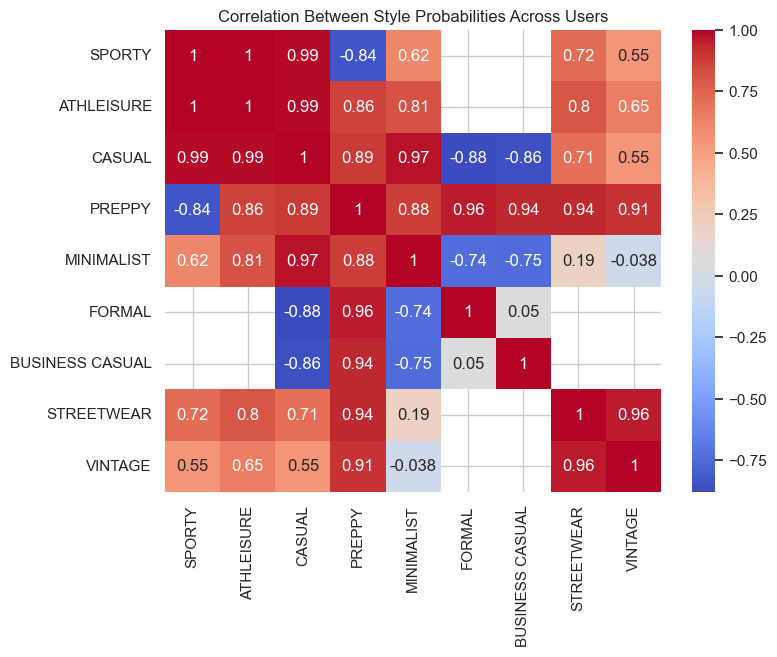

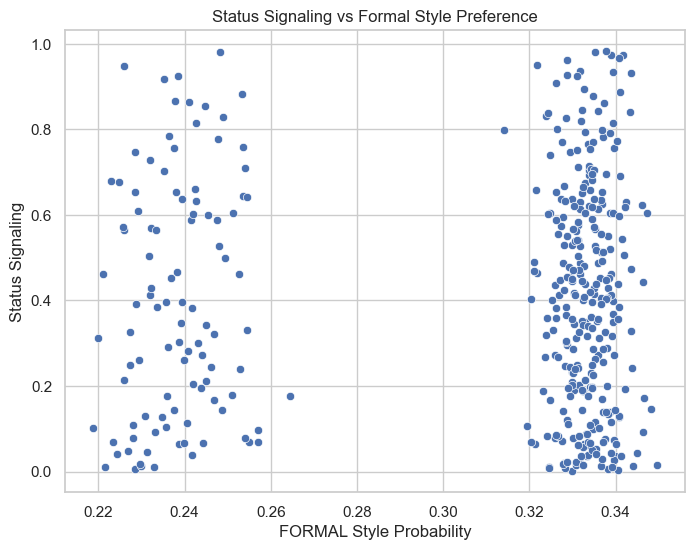

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.generate_users import Simulated_User

# ----------------------
# 1️⃣ Generate 1000 users and collect their preferences
# ----------------------
num_users = 1000

all_preferences = {cat: [] for cat in ['style', 'clothing_type', 'fitting', 'sizing', 'pricing', 'material', 'color_scheme']}

for _ in range(num_users):
    user = Simulated_User()
    prefs = user.get_clothing_preferences()
    for cat in all_preferences.keys():
        all_preferences[cat].append(prefs[cat])

# ----------------------
# 2️⃣ Convert to DataFrames: one column per option
# ----------------------
dfs = {}
for cat, list_of_dicts in all_preferences.items():
    # Each row = one user, each column = option probability
    df = pd.DataFrame(list_of_dicts)
    dfs[cat] = df

# ----------------------
# 3️⃣ Visualize distributions for each category
# ----------------------
sns.set(style="whitegrid")

for cat, df in dfs.items():
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df)
    plt.title(f"Distribution of {cat.capitalize()} Preferences Across {num_users} Users")
    plt.ylabel("Probability")
    plt.xticks(rotation=45)
    plt.show()

# ----------------------
# 4️⃣ Optional: Correlation between options within a category
# ----------------------
# Example: correlation between style probabilities
plt.figure(figsize=(8, 6))
sns.heatmap(dfs['style'].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Style Probabilities Across Users")
plt.show()

# ----------------------
# 5️⃣ Optional: Correlation between latent variables and a preference option
# ----------------------
latent_vars = []
for _ in range(num_users):
    user = Simulated_User()
    latent_vars.append(user.get_latent_variables())

df_latent = pd.DataFrame(latent_vars)

# Example: correlate style['FORMAL'] probability with 'status_signaling'
formal_probs = dfs['style']['FORMAL']
plt.figure(figsize=(8, 6))
sns.scatterplot(x=formal_probs, y=df_latent['status_signaling'])
plt.xlabel("FORMAL Style Probability")
plt.ylabel("Status Signaling")
plt.title("Status Signaling vs Formal Style Preference")
plt.show()

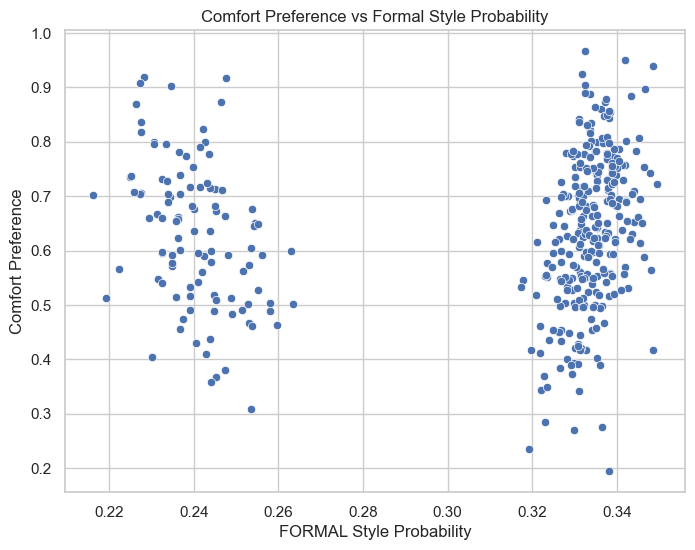

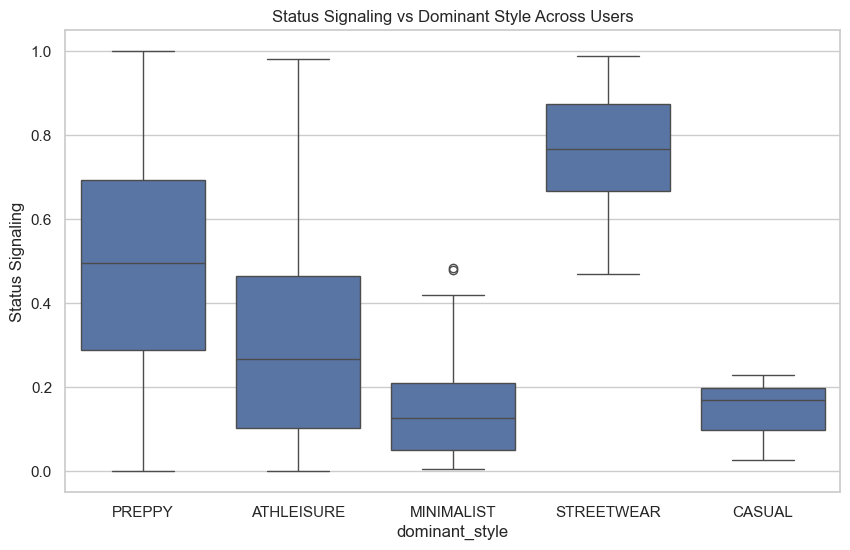

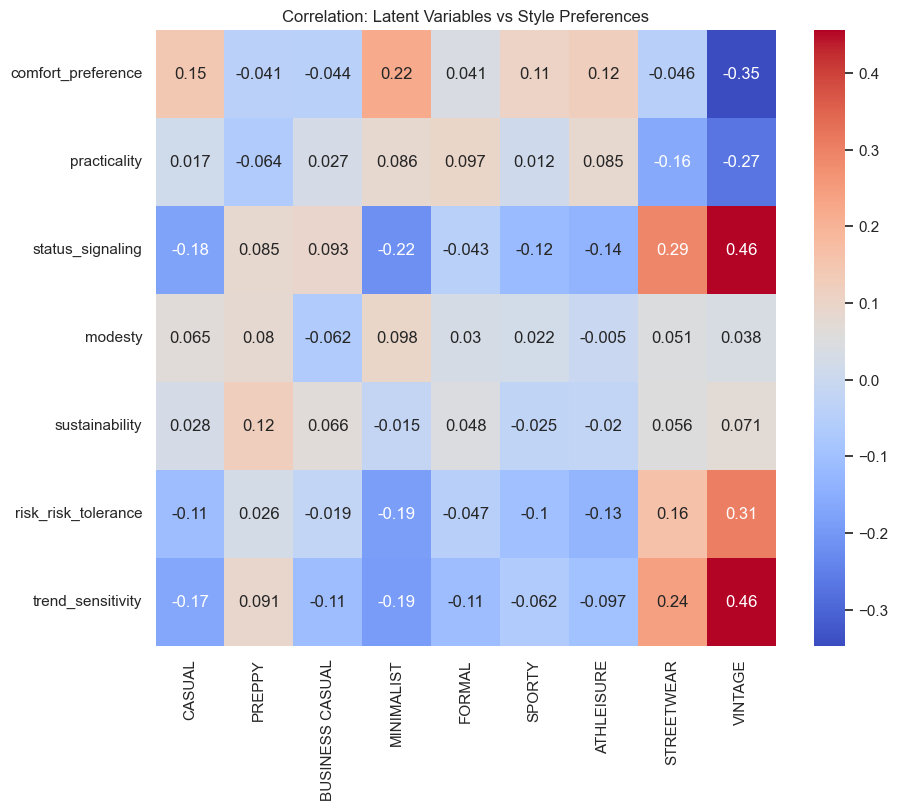

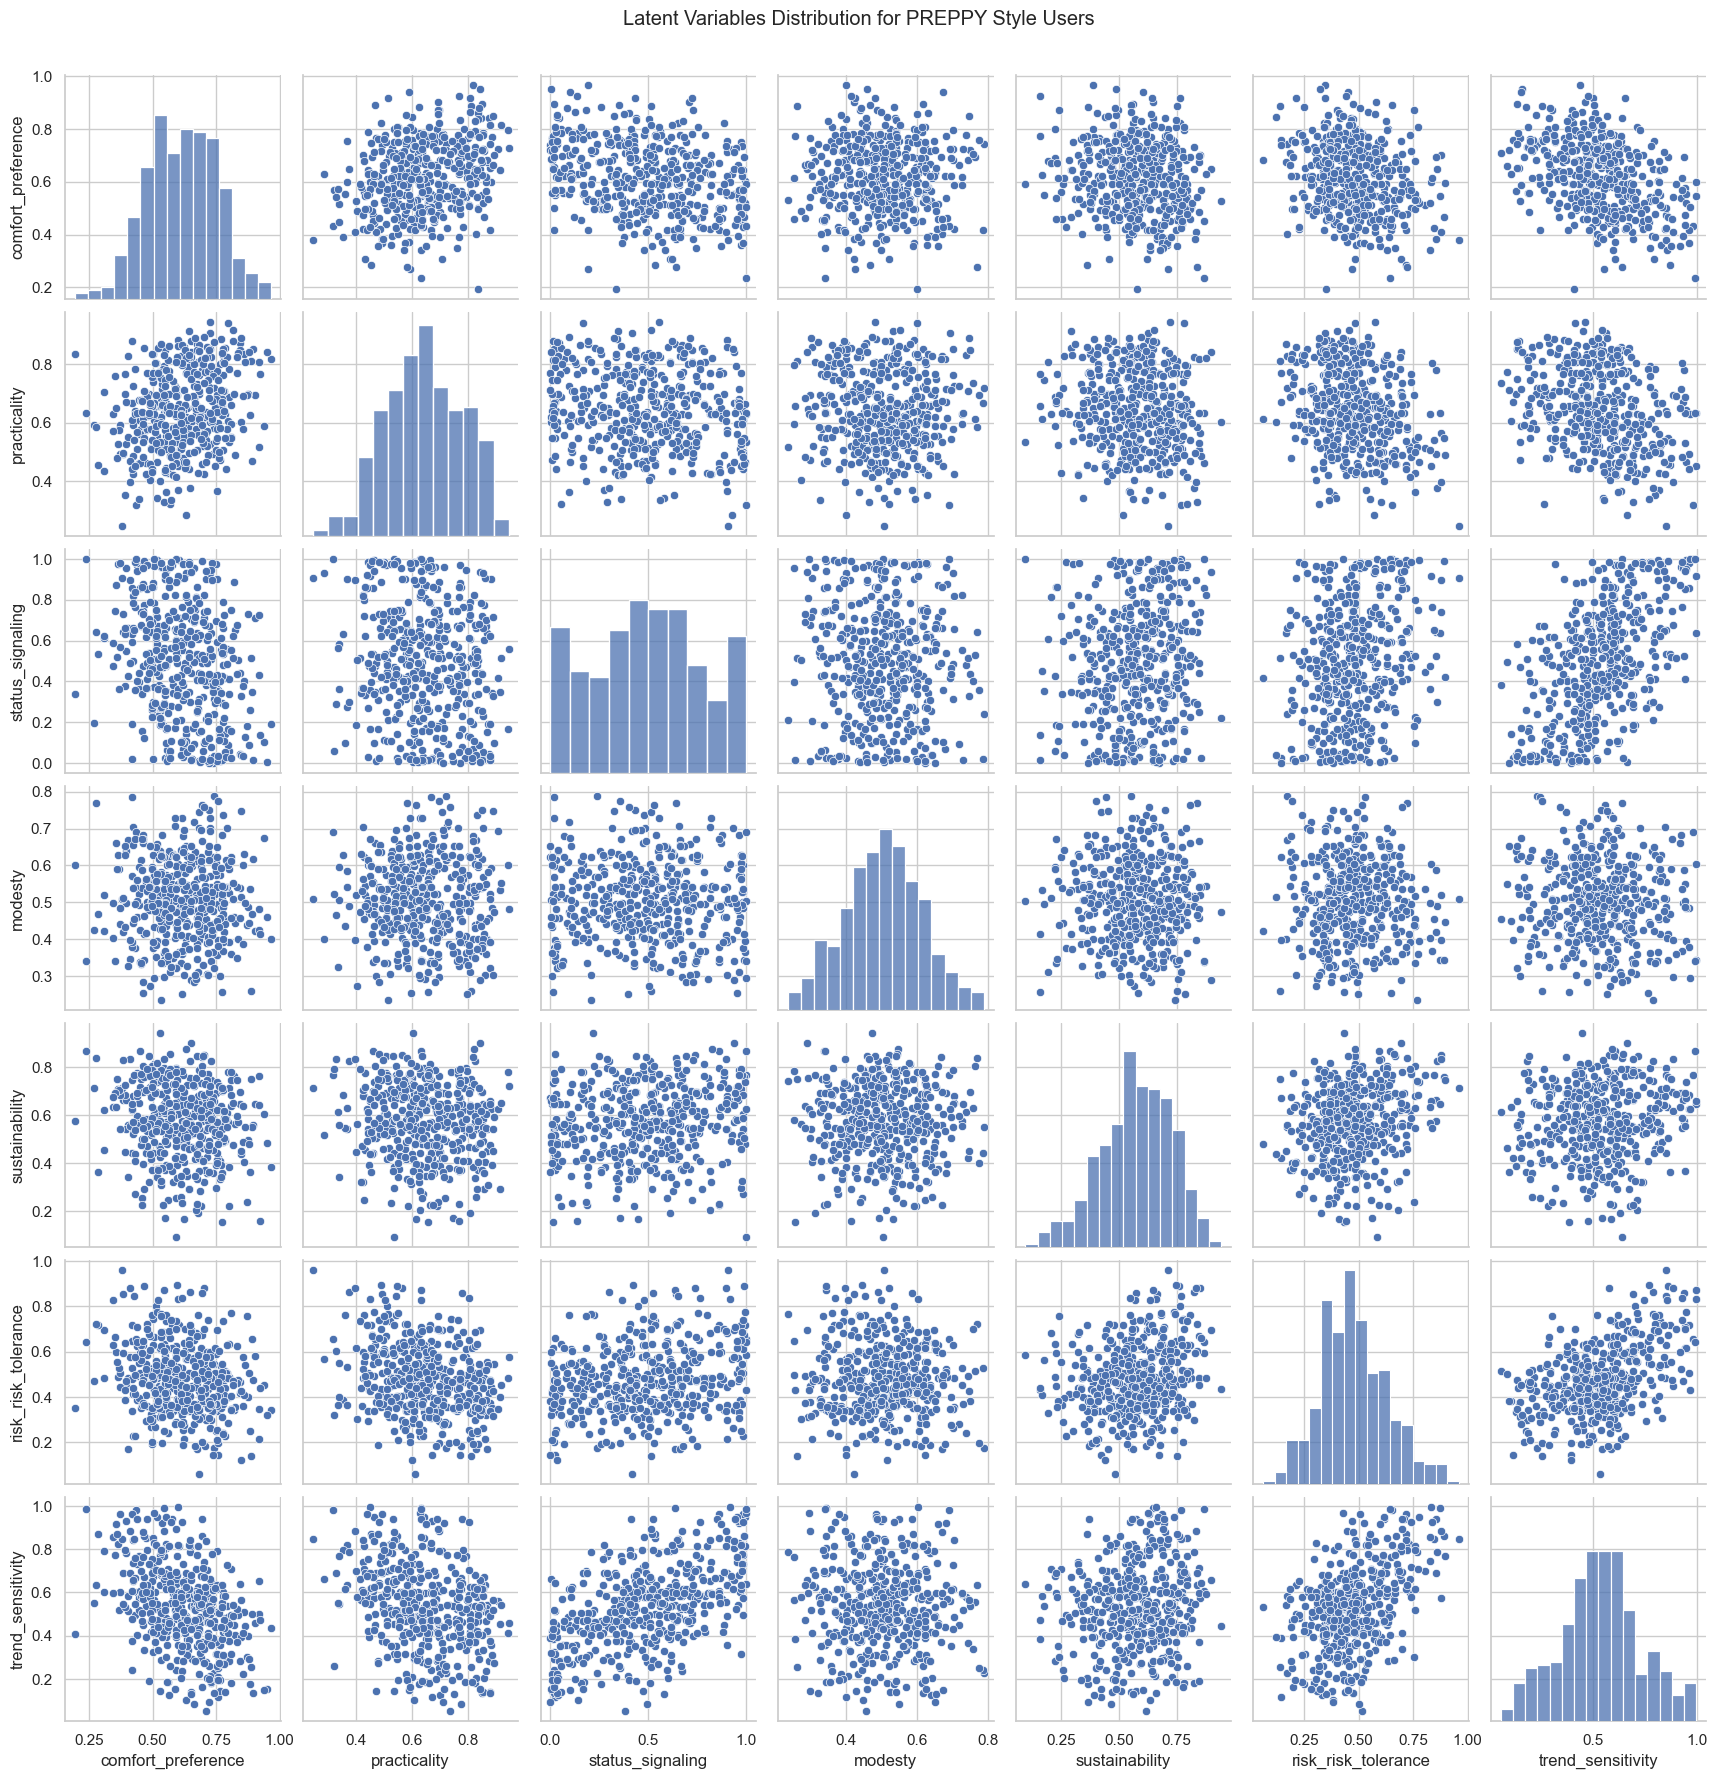

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from utils.generate_users import Simulated_User

num_users = 1000

# Lists to store data
preference_data = {cat: [] for cat in ['style', 'clothing_type', 'fitting', 'sizing', 'pricing', 'material', 'color_scheme']}
latent_data = []

# Generate users
for _ in range(num_users):
    user = Simulated_User()
    prefs = user.get_clothing_preferences()
    latent_vars = user.get_latent_variables()
    
    for cat in preference_data.keys():
        preference_data[cat].append(prefs[cat])
    latent_data.append(latent_vars)

# Convert to DataFrames
dfs_pref = {cat: pd.DataFrame(list_of_dicts) for cat, list_of_dicts in preference_data.items()}
df_latent = pd.DataFrame(latent_data)

# Merge latent variable with style['FORMAL']
df_compare = pd.concat([df_latent['comfort_preference'], dfs_pref['style']['FORMAL']], axis=1)

plt.figure(figsize=(8,6))
sns.scatterplot(x='FORMAL', y='comfort_preference', data=df_compare)
plt.xlabel("FORMAL Style Probability")
plt.ylabel("Comfort Preference")
plt.title("Comfort Preference vs Formal Style Probability")
plt.show()

# Identify dominant style per user
dominant_style = dfs_pref['style'].idxmax(axis=1)
df_compare = pd.concat([df_latent['status_signaling'], dominant_style.rename('dominant_style')], axis=1)

plt.figure(figsize=(10,6))
sns.boxplot(x='dominant_style', y='status_signaling', data=df_compare)
plt.title("Status Signaling vs Dominant Style Across Users")
plt.ylabel("Status Signaling")
plt.show()

# Example for style
df_style_latent = pd.concat([df_latent, dfs_pref['style']], axis=1)
corr = df_style_latent.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr.loc[df_latent.columns, dfs_pref['style'].columns], annot=True, cmap='coolwarm')
plt.title("Correlation: Latent Variables vs Style Preferences")
plt.show()

# Combine latent + dominant style
dominant_style = dfs_pref['style'].idxmax(axis=1)
df_combined = pd.concat([df_latent, dominant_style.rename('dominant_style')], axis=1)

# Pairplot for users whose dominant style is PREPPY
sns.pairplot(df_combined[df_combined['dominant_style'] == 'PREPPY'], vars=df_latent.columns)
plt.suptitle("Latent Variables Distribution for PREPPY Style Users", y=1.02)
plt.show()